<a href="https://colab.research.google.com/github/princepatel2004/Edunet-Summer-Intership-/blob/main/%5BDay_5%5D_10_02_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day-5 10-07-26

## Import Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Display all columns
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_excel("/Green_Sustainability_Dataset.xlsx")
df.head()

,Country,Region,Energy_Source,Population_Million,GDP_Billion_USD,Renewable_Energy_GWh,CO2_Emissions_MT,Recycling_Rate,Green_Jobs_Thousands,Sustainability_Score
0,China,Asia,Solar,71,24449.0,5306,696.0,53.0,320,32.70
1,Australia,Oceania,Solar,884,1191.0,1288,858.0,NaN,143,17.58
2,Brazil,America,Hydro,427,23612.0,11447,506.0,78.0,648,61.88
3,India,Asia,Hydro,346,23026.0,7724,600.0,60.0,445,40.69
4,China,Asia,Solar,209,12599.0,2384,871.0,69.0,293,26.77


# Information about Dataset

In [11]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               120 non-null    object 
 1   Region                120 non-null    object 
 2   Energy_Source         120 non-null    object 
 3   Population_Million    120 non-null    int64  
 4   GDP_Billion_USD       114 non-null    float64
 5   Renewable_Energy_GWh  120 non-null    int64  
 6   CO2_Emissions_MT      114 non-null    float64
 7   Recycling_Rate        114 non-null    float64
 8   Green_Jobs_Thousands  120 non-null    int64  
 9   Sustainability_Score  120 non-null    float64
dtypes: float64(4), int64(3), object(3)
memory usage: 9.5+ KB


## Feature Description

* Country - Name of the country where the sustainability data is recorded.

* Region - Geographic region of the country.

* Energy_Source - Primary renewable energy source used by the country.

* Population_Million - Total population of the country, measured in millions.

* GDP_Billion_USD - GDP of the country, measured in billions of US dollars.

* Renewable_Energy_GWh - Annual renewable electricity generation, measured in gigawatt-hours (GWh).

* CO2_Emissions_MT - Annual carbon dioxide (CO₂) emissions, measured in million metric tonnes (MT).

* Recycling_Rate - Percentage of waste recycled, representing the country's recycling performance.

* Green_Jobs_Thousands - Estimated number of green jobs available, measured in thousands.

* Sustainability_Score - Overall sustainability performance score.



## General Observations

- The dataset contains 120 observations.

- It contains both categorical and numerical columns.

- Renewable Energy Production, GDP, Population and CO₂ Emissions are numerical variables.

- Country, Region and Energy Source are categorical variables.

- Some numerical columns contain missing values.

- Sustainability Score appears to depend on renewable energy generation, recycling rate and CO₂ emissions.

## Check and Handle Missing Values

In [12]:
df.isnull().sum()

,0
Country,0
Region,0
Energy_Source,0
Population_Million,0
GDP_Billion_USD,6
Renewable_Energy_GWh,0
CO2_Emissions_MT,6
Recycling_Rate,6
Green_Jobs_Thousands,0
Sustainability_Score,0


In [13]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.isnull().sum()

,0
Country,0
Region,0
Energy_Source,0
Population_Million,0
GDP_Billion_USD,0
Renewable_Energy_GWh,0
CO2_Emissions_MT,0
Recycling_Rate,0
Green_Jobs_Thousands,0
Sustainability_Score,0


## Feature Engineering

A new feature called Renewable Energy per GDP is created.

Renewable Energy per GDP = ( Renewable_Energy_GWh ) / ( GDP_Billion_USD )

In [14]:
df["Renewable_per_GDP"] = (
    df["Renewable_Energy_GWh"] /
    df["GDP_Billion_USD"]
)

df.head()

,Country,Region,Energy_Source,Population_Million,GDP_Billion_USD,Renewable_Energy_GWh,CO2_Emissions_MT,Recycling_Rate,Green_Jobs_Thousands,Sustainability_Score,Renewable_per_GDP
0,China,Asia,Solar,71,24449.0,5306,696.0,53.000000,320,32.70,0.217023
1,Australia,Oceania,Solar,884,1191.0,1288,858.0,57.824561,143,17.58,1.081444
2,Brazil,America,Hydro,427,23612.0,11447,506.0,78.000000,648,61.88,0.484796
3,India,Asia,Hydro,346,23026.0,7724,600.0,60.000000,445,40.69,0.335447
4,China,Asia,Solar,209,12599.0,2384,871.0,69.000000,293,26.77,0.189221


# Data Visualization using Seaborn

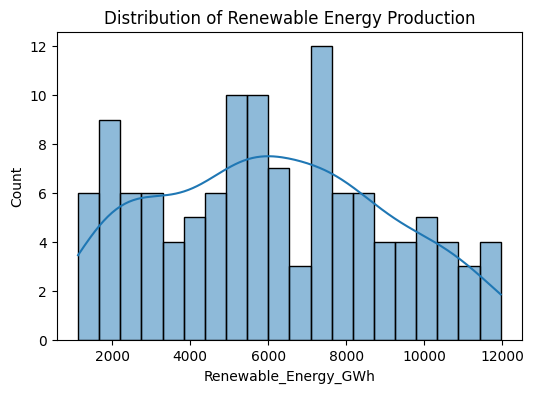

In [16]:
# HISTOGRAM
plt.figure(figsize=(6,4))

sns.histplot(df["Renewable_Energy_GWh"], bins=20, kde=True)
plt.title("Distribution of Renewable Energy Production")
plt.show()

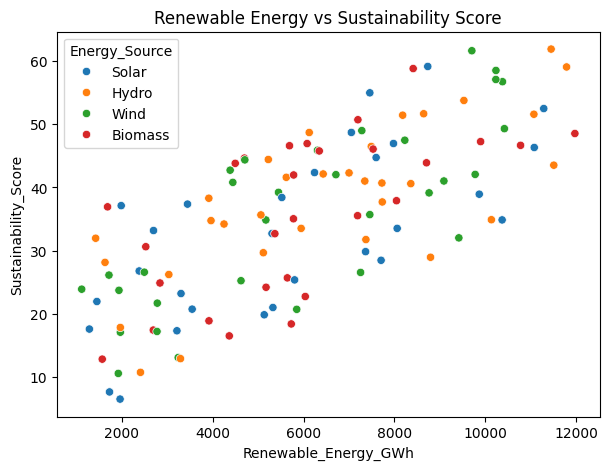

In [17]:
# SCATTER PLOT
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Renewable_Energy_GWh",
    y="Sustainability_Score",
    hue="Energy_Source",
    data=df
)

plt.title("Renewable Energy vs Sustainability Score")

plt.show()

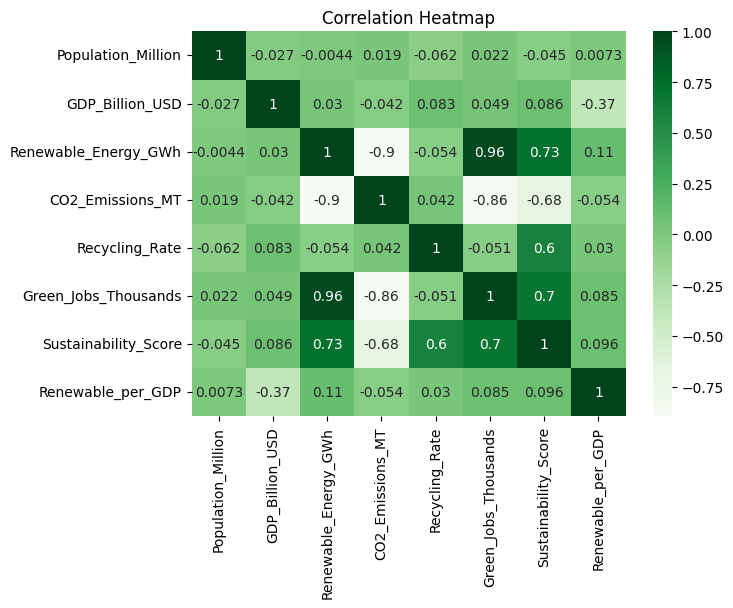

In [20]:
plt.figure(figsize=(7,5))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Greens"
)

plt.title("Correlation Heatmap")

plt.show()

## Scaling Numerical Features

In [21]:
scaler = StandardScaler()

num_cols = [
    "Population_Million",
    "GDP_Billion_USD",
    "Renewable_Energy_GWh",
    "CO2_Emissions_MT",
    "Recycling_Rate",
    "Green_Jobs_Thousands",
    "Sustainability_Score",
    "Renewable_per_GDP"
]

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,Country,Region,Energy_Source,Population_Million,GDP_Billion_USD,Renewable_Energy_GWh,CO2_Emissions_MT,Recycling_Rate,Green_Jobs_Thousands,Sustainability_Score,Renewable_per_GDP
0,China,Asia,Solar,-1.493494,1.584062,-0.257640,-0.051612,-2.591688e-01,-0.569319,-0.234211,-0.274192
1,Australia,Oceania,Solar,0.426561,-1.720808,-1.642256,1.037731,-3.816938e-16,-1.728367,-1.399292,0.007240
2,Brazil,America,Hydro,-0.652732,1.465128,1.858569,-1.329237,1.083797e+00,1.578520,2.014273,-0.187012
3,India,Asia,Hydro,-0.844029,1.381859,0.575611,-0.697149,1.168616e-01,0.249217,0.381464,-0.235636
4,China,Asia,Solar,-1.167581,-0.099776,-1.264571,1.125147,6.003292e-01,-0.746123,-0.691150,-0.283243


## Encoding Categorical Variables

In [22]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Country",
        "Region",
        "Energy_Source"
    ],
    dtype=int
)

df_encoded.head()

,Population_Million,GDP_Billion_USD,Renewable_Energy_GWh,CO2_Emissions_MT,Recycling_Rate,Green_Jobs_Thousands,Sustainability_Score,Renewable_per_GDP,Country_Australia,Country_Brazil,Country_Canada,Country_China,Country_France,Country_Germany,Country_India,Country_Japan,Country_Norway,Country_USA,Region_America,Region_Asia,Region_Europe,Region_Oceania,Energy_Source_Biomass,Energy_Source_Hydro,Energy_Source_Solar,Energy_Source_Wind
0,-1.493494,1.584062,-0.257640,-0.051612,-2.591688e-01,-0.569319,-0.234211,-0.274192,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0
1,0.426561,-1.720808,-1.642256,1.037731,-3.816938e-16,-1.728367,-1.399292,0.007240,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,-0.652732,1.465128,1.858569,-1.329237,1.083797e+00,1.578520,2.014273,-0.187012,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
3,-0.844029,1.381859,0.575611,-0.697149,1.168616e-01,0.249217,0.381464,-0.235636,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0
4,-1.167581,-0.099776,-1.264571,1.125147,6.003292e-01,-0.746123,-0.691150,-0.283243,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0


# SUMMARY & INSIGHTS

### Dataset Overview

- The dataset contains sustainability-related information from different countries.
- It includes both numerical and categorical variables.

### Missing Value Handling

- Missing values were present in GDP, CO₂ Emissions and Recycling Rate.
- These values were replaced using the mean because it is robust to outliers.

### Feature Engineering

- A new feature, Renewable_per_GDP, was created to measure renewable energy efficiency relative to GDP.

### Data Visualization

- Histograms showed the distribution of renewable energy generation.
- Scatter plots suggested a positive relationship between renewable energy generation and sustainability score.
- Heatmaps revealed correlations among numerical variables.

### Data Preprocessing

- StandardScaler was applied to normalize numerical features.
- One-Hot Encoding was used for categorical variables because there is no natural order among categories.

### Conclusion

The dataset has been successfully cleaned, visualized and preprocessed. It is now suitable for statistical analysis and machine learning applications.